# India Economic Indicators — Exploratory Data Analysis

Working through 11 World Bank macro indicators for India (1960–2025) before any modelling, to understand what the data can and cannot support.

**Questions this notebook answers:**
1. How complete is the data, and where does it start?
2. Did 1991 actually change India's growth?
3. Which indicators move together?
4. How has the economy's structure changed?
5. Is annual GDP growth forecastable at all?

That last question is the one that decides whether the modelling step is worth doing.

## 1. Setup

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()

sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.dpi'] = 110
pd.set_option('display.width', 120)
pd.set_option('display.max_columns', 20)

df = pd.read_csv(ROOT / 'data' / 'processed' / 'india_indicators.csv',
                 index_col='year')
TARGET = 'gdp_growth_pct'

print(f'Shape: {df.shape[0]} years x {df.shape[1]} indicators')
print(f'Years: {df.index.min()} to {df.index.max()}')

Shape: 66 years x 11 indicators
Years: 1960 to 2025


## 2. First look

In [2]:
df.head()

,agriculture_pct_gdp,exports_pct_gdp,fdi_inflow_pct_gdp,gdp_growth_pct,gdp_per_capita_growth_pct,imports_pct_gdp,industry_pct_gdp,inflation_cpi_pct,services_pct_gdp,unemployment_pct,trade_balance_pct_gdp
year,,,,,,,,,,,
1960,41.741335,4.463156,NaN,NaN,NaN,6.833677,20.834343,1.779878,38.782462,NaN,-2.370520
1961,41.092482,4.303586,NaN,3.722743,1.266649,5.957576,21.434844,1.695213,38.325875,NaN,-1.653990
1962,39.065969,4.168975,NaN,2.931128,0.518502,6.031815,22.052600,3.632215,39.935845,NaN,-1.862840
1963,39.825352,4.280503,NaN,5.994353,3.536491,5.906834,21.879476,2.946161,38.095180,NaN,-1.626331
1964,41.343717,3.725551,NaN,7.452950,4.966119,5.684998,20.955289,13.355261,36.340821,NaN,-1.959447


In [3]:
df.dtypes.to_frame('dtype')

,dtype
agriculture_pct_gdp,float64
exports_pct_gdp,float64
fdi_inflow_pct_gdp,float64
gdp_growth_pct,float64
gdp_per_capita_growth_pct,float64
imports_pct_gdp,float64
industry_pct_gdp,float64
inflation_cpi_pct,float64
services_pct_gdp,float64
unemployment_pct,float64


## 3. Coverage and missingness

Before trusting any cross-indicator comparison, check where each series actually starts. Uneven coverage is the most common silent failure in panel data — a model will happily drop every row where one column is missing without telling you.

In [4]:
coverage = pd.DataFrame({
    'first_year': df.apply(lambda s: s.first_valid_index()),
    'last_year': df.apply(lambda s: s.last_valid_index()),
    'observations': df.notna().sum(),
    'missing': df.isna().sum(),
})
coverage['pct_complete'] = (
    coverage['observations'] / len(df) * 100
).round(1)
coverage.sort_values('observations')

,first_year,last_year,observations,missing,pct_complete
unemployment_pct,1991,2025,35,31,53.0
fdi_inflow_pct_gdp,1970,2025,56,10,84.8
gdp_per_capita_growth_pct,1961,2025,65,1,98.5
gdp_growth_pct,1961,2025,65,1,98.5
agriculture_pct_gdp,1960,2025,66,0,100.0
imports_pct_gdp,1960,2025,66,0,100.0
industry_pct_gdp,1960,2025,66,0,100.0
exports_pct_gdp,1960,2025,66,0,100.0
inflation_cpi_pct,1960,2025,66,0,100.0
services_pct_gdp,1960,2025,66,0,100.0


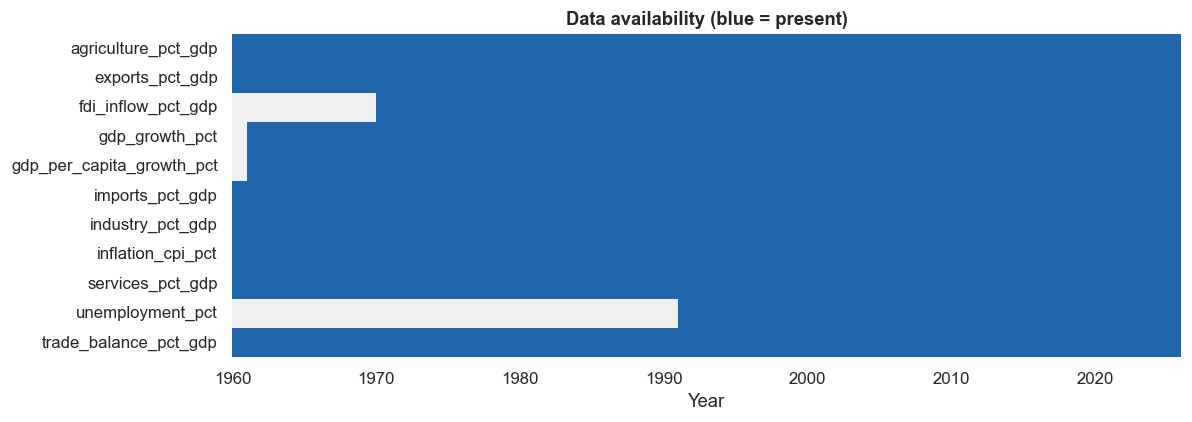

In [5]:
fig, ax = plt.subplots(figsize=(11, 4))
sns.heatmap(df.notna().T, cbar=False, cmap=['#f0f0f0', '#2166ac'], ax=ax)
ax.set_xticks(range(0, len(df), 10))
ax.set_xticklabels(df.index[::10], rotation=0)
ax.set_title('Data availability (blue = present)', weight='bold')
ax.set_xlabel('Year')
plt.tight_layout()
plt.show()

Unemployment only starts in 1991 and FDI in 1970, while the national accounts series run from 1960.

**Decision:** any analysis that needs all indicators at once starts at **1991**. Analyses that only need GDP growth can use the full history.

## 4. Summary statistics

In [6]:
summary = df.describe().T[['count', 'mean', 'std', 'min', '50%', 'max']]
summary.columns = ['count', 'mean', 'std', 'min', 'median', 'max']
summary.round(2)

,count,mean,std,min,median,max
agriculture_pct_gdp,66.0,27.30,9.31,16.03,26.98,42.75
exports_pct_gdp,66.0,11.76,7.45,3.31,9.34,25.43
fdi_inflow_pct_gdp,56.0,0.80,0.87,-0.03,0.61,3.62
gdp_growth_pct,65.0,5.26,3.19,-5.78,5.99,9.69
gdp_per_capita_growth_pct,65.0,3.32,3.31,-7.42,3.76,8.79
imports_pct_gdp,66.0,13.64,8.44,3.71,9.70,31.26
industry_pct_gdp,66.0,25.87,2.89,20.09,26.48,31.14
inflation_cpi_pct,66.0,7.23,4.81,-7.63,6.53,28.60
services_pct_gdp,66.0,40.40,5.22,32.95,38.21,50.08
unemployment_pct,35.0,7.18,1.07,4.17,7.61,7.86


## 5. Growth over time

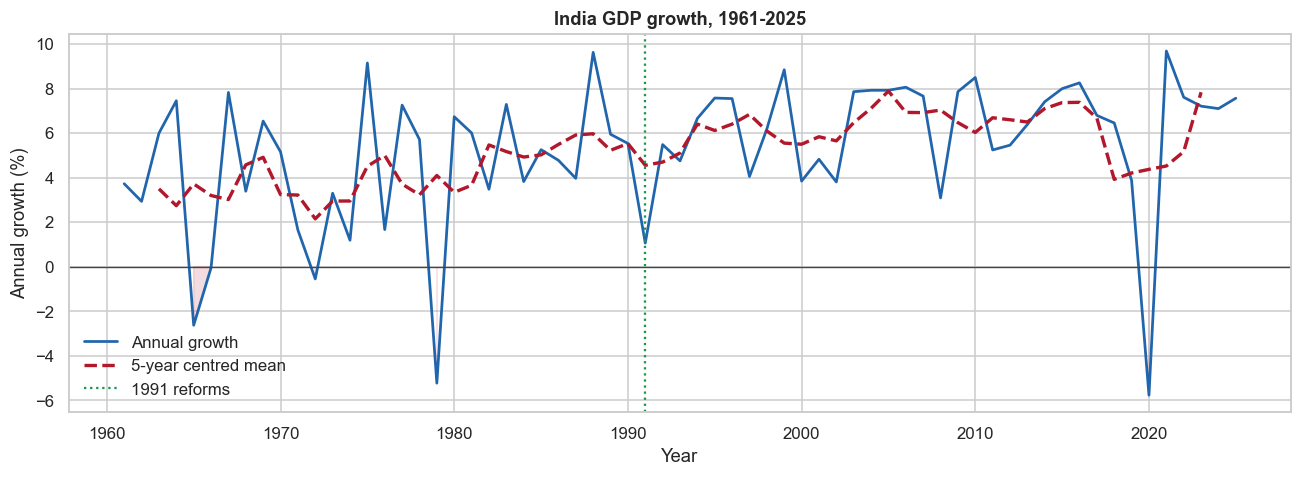

Mean   : 5.26%
Median : 5.99%
Std    : 3.19 pp
Min    : -5.78% (2020)
Max    : 9.69% (2021)


In [7]:
growth = df[TARGET].dropna()

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(growth.index, growth.values, color='#2166ac', lw=1.8,
        label='Annual growth')
ax.plot(growth.index, growth.rolling(5, center=True).mean(),
        color='#b2182b', lw=2.2, ls='--', label='5-year centred mean')
ax.axhline(0, color='#444', lw=0.9)
ax.axvline(1991, color='#1a9850', lw=1.5, ls=':', label='1991 reforms')
ax.fill_between(growth.index, 0, growth.values,
                where=growth.values < 0, color='#b2182b', alpha=0.15)
ax.set_title('India GDP growth, 1961-2025', weight='bold')
ax.set_xlabel('Year'); ax.set_ylabel('Annual growth (%)')
ax.legend(frameon=False)
plt.tight_layout(); plt.show()

print(f'Mean   : {growth.mean():.2f}%')
print(f'Median : {growth.median():.2f}%')
print(f'Std    : {growth.std():.2f} pp')
print(f'Min    : {growth.min():.2f}% ({growth.idxmin()})')
print(f'Max    : {growth.max():.2f}% ({growth.idxmax()})')

## 6. Did 1991 change anything?

The reforms are the obvious structural break to test. Comparing means alone would miss half the story, so volatility is compared too.

In [8]:
pre = growth[growth.index < 1991]
post = growth[growth.index >= 1991]

comparison = pd.DataFrame({
    'years': [len(pre), len(post)],
    'mean_growth': [pre.mean(), post.mean()],
    'volatility': [pre.std(), post.std()],
    'min': [pre.min(), post.min()],
    'max': [pre.max(), post.max()],
    'negative_years': [(pre < 0).sum(), (post < 0).sum()],
}, index=['1961-1990', '1991-2025']).round(2)
comparison

,years,mean_growth,volatility,min,max,negative_years
1961-1990,30,4.23,3.36,-5.24,9.63,4
1991-2025,35,6.14,2.80,-5.78,9.69,1


In [9]:
from scipy import stats

t_stat, p_value = stats.ttest_ind(post, pre, equal_var=False)
print(f'Difference in means : {post.mean() - pre.mean():+.2f} pp')
print(f"Welch t-test        : t={t_stat:.2f}, p={p_value:.4f}")
print()
if p_value < 0.05:
    print('The difference is statistically significant at the 5% level.')
else:
    print('The difference is not significant at the 5% level.')
print()
print('Caveat: the two samples are consecutive periods of one time')
print('series, not independent draws. The test is indicative, not')
print('conclusive - anything that trended upward over 65 years would')
print('also split this way.')

Difference in means : +1.91 pp
Welch t-test        : t=2.46, p=0.0169

The difference is statistically significant at the 5% level.

Caveat: the two samples are consecutive periods of one time
series, not independent draws. The test is indicative, not
conclusive - anything that trended upward over 65 years would
also split this way.


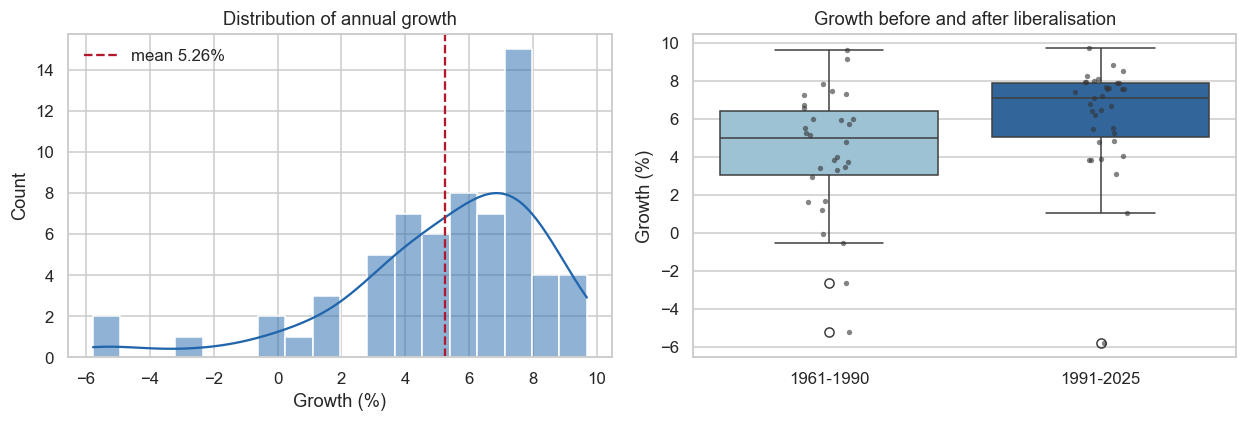

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4))

sns.histplot(growth, bins=18, kde=True, ax=axes[0], color='#2166ac')
axes[0].axvline(growth.mean(), color='#b2182b', ls='--',
                label=f'mean {growth.mean():.2f}%')
axes[0].set_title('Distribution of annual growth')
axes[0].set_xlabel('Growth (%)'); axes[0].legend(frameon=False)

box = pd.DataFrame({
    'growth': pd.concat([pre, post]),
    'era': ['1961-1990'] * len(pre) + ['1991-2025'] * len(post),
})
sns.boxplot(data=box, x='era', y='growth', ax=axes[1], hue='era',
            palette=['#92c5de', '#2166ac'], legend=False)
sns.stripplot(data=box, x='era', y='growth', ax=axes[1],
              color='#333', size=3.5, alpha=0.6)
axes[1].set_title('Growth before and after liberalisation')
axes[1].set_xlabel(''); axes[1].set_ylabel('Growth (%)')
plt.tight_layout(); plt.show()

## 7. What moves with growth?

Correlations are computed on the 1991–2025 window where every indicator is present.

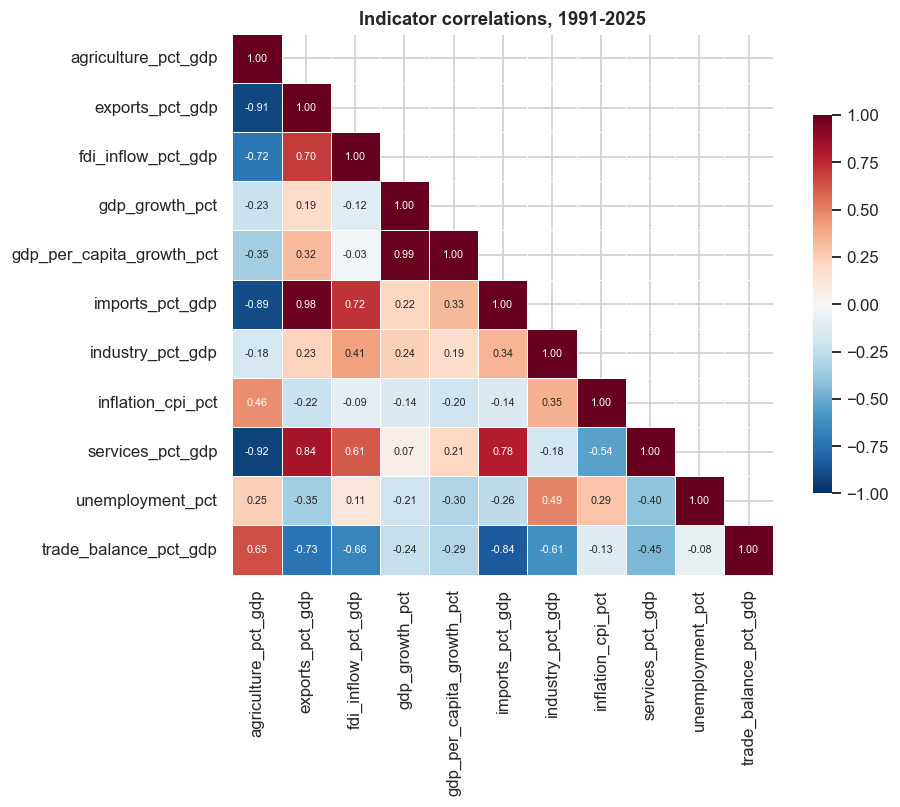

In [11]:
window = df.loc[df.index >= 1991]
corr = window.corr()

fig, ax = plt.subplots(figsize=(9.5, 7.5))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.5,
            annot_kws={'size': 7}, cbar_kws={'shrink': 0.7}, ax=ax)
ax.set_title('Indicator correlations, 1991-2025', weight='bold')
plt.tight_layout(); plt.show()

In [12]:
growth_corr = (
    corr[TARGET]
    .drop([TARGET, 'gdp_per_capita_growth_pct'])
    .sort_values(key=abs, ascending=False)
    .round(3)
)
print('Correlation with GDP growth:')
print(growth_corr.to_string())
print()
print(f'Strongest absolute correlation: {growth_corr.abs().max():.3f}')
print()
print('Every one of these is weak. Nothing in this panel has a strong')
print('linear relationship with growth even in the same year, which is')
print('an early warning for the forecasting step.')

Correlation with GDP growth:
trade_balance_pct_gdp   -0.241
industry_pct_gdp         0.239
agriculture_pct_gdp     -0.226
imports_pct_gdp          0.216
unemployment_pct        -0.210
exports_pct_gdp          0.193
inflation_cpi_pct       -0.141
fdi_inflow_pct_gdp      -0.119
services_pct_gdp         0.068

Strongest absolute correlation: 0.241

Every one of these is weak. Nothing in this panel has a strong
linear relationship with growth even in the same year, which is
an early warning for the forecasting step.


## 8. Structural change

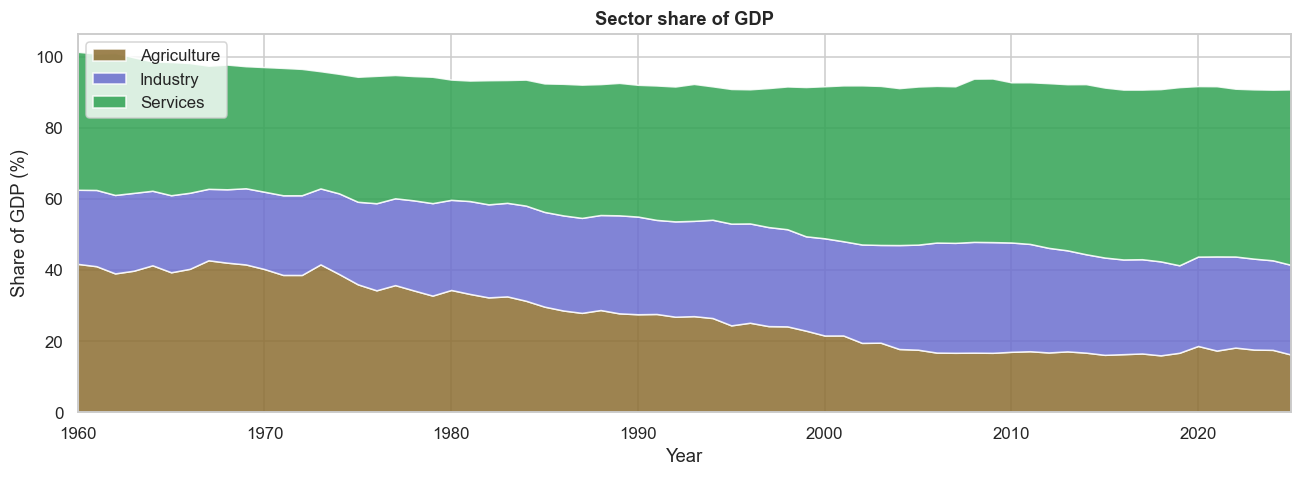

,first,last,change_pp
agriculture_pct_gdp,41.7,16.2,-25.5
industry_pct_gdp,20.8,25.2,4.4
services_pct_gdp,38.8,49.3,10.6


In [13]:
sectors = df[['agriculture_pct_gdp', 'industry_pct_gdp',
              'services_pct_gdp']].dropna()

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.stackplot(sectors.index,
             sectors['agriculture_pct_gdp'],
             sectors['industry_pct_gdp'],
             sectors['services_pct_gdp'],
             labels=['Agriculture', 'Industry', 'Services'],
             colors=['#8c6d31', '#6b6ecf', '#31a354'], alpha=0.85)
ax.set_xlim(sectors.index.min(), sectors.index.max())
ax.set_title('Sector share of GDP', weight='bold')
ax.set_xlabel('Year'); ax.set_ylabel('Share of GDP (%)')
ax.legend(loc='upper left')
plt.tight_layout(); plt.show()

shift = pd.DataFrame({
    'first': sectors.iloc[0],
    'last': sectors.iloc[-1],
})
shift['change_pp'] = (shift['last'] - shift['first']).round(1)
shift.round(1)

Agriculture lost roughly 23 percentage points of GDP share and services gained almost all of it. Industry is close to flat.

This is not the standard development path — most industrialising economies move agriculture → industry → services. India went agriculture → services directly, which matters because services growth absorbs fewer low-skilled workers per unit of output.

## 9. Outlier years

In [14]:
q1, q3 = growth.quantile([0.25, 0.75])
iqr = q3 - q1
low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr

outliers = growth[(growth < low) | (growth > high)]
print(f'IQR fence: [{low:.2f}, {high:.2f}]')
print(f'Outlier years: {len(outliers)}')
print()
print(outliers.round(2).to_string())
print()
print('All three are known shocks - the 1965 war and drought, the 1979')
print('oil shock, and COVID-19 in 2020. They are real events, not data')
print('errors, so they stay in the dataset.')

IQR fence: [-1.80, 13.19]
Outlier years: 3

year
1965   -2.64
1979   -5.24
2020   -5.78

All three are known shocks - the 1965 war and drought, the 1979
oil shock, and COVID-19 in 2020. They are real events, not data
errors, so they stay in the dataset.


## 10. Is growth forecastable at all?

This is the question that decides whether modelling is worthwhile. Two checks:

- **Stationarity (ADF test).** If the series is stationary around a constant mean, the mean itself is a strong forecast and there is no trend to extrapolate.
- **Autocorrelation.** If this year's growth carries no information about next year's, lag features cannot help.

In [15]:
from statsmodels.tsa.stattools import adfuller

adf_stat, adf_p, _, n_obs, crit, _ = adfuller(growth, autolag='AIC')
print('Augmented Dickey-Fuller test on GDP growth')
print(f'  statistic     : {adf_stat:.3f}')
print(f'  p-value       : {adf_p:.4f}')
print(f'  observations  : {n_obs}')
for level, value in crit.items():
    print(f'  critical {level:>4} : {value:.3f}')
print()
if adf_p < 0.05:
    print('Stationary: the series reverts to a constant mean.')
    print('A mean forecast is therefore a genuinely strong baseline,')
    print('and there is no persistent trend for a model to exploit.')
else:
    print('Non-stationary: the series wanders and differencing is needed.')

Augmented Dickey-Fuller test on GDP growth
  statistic     : -7.653
  p-value       : 0.0000
  observations  : 64
  critical   1% : -3.537
  critical   5% : -2.908
  critical  10% : -2.591

Stationary: the series reverts to a constant mean.
A mean forecast is therefore a genuinely strong baseline,
and there is no persistent trend for a model to exploit.


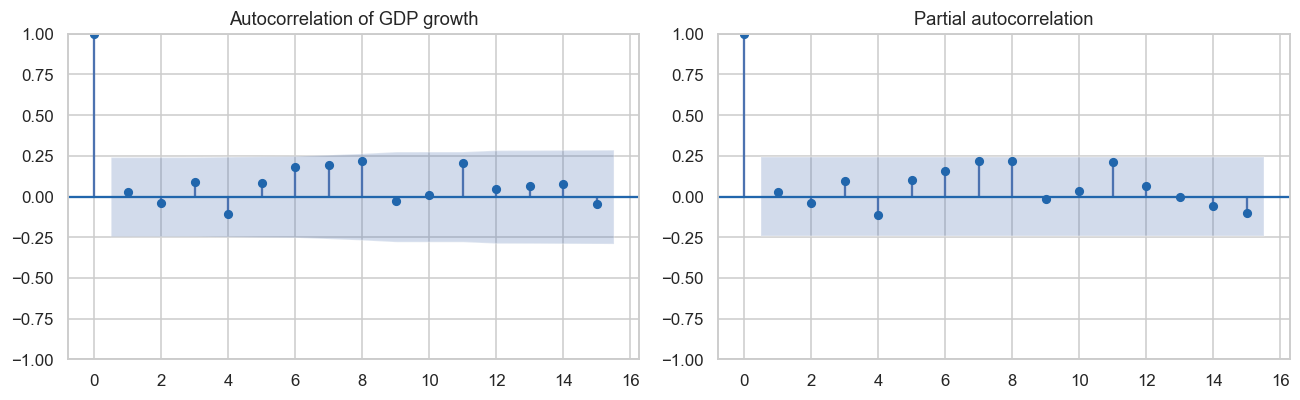

Lag-1 autocorrelation : 0.026
Lag-2 autocorrelation : -0.039


In [16]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
plot_acf(growth, lags=15, ax=axes[0], color='#2166ac')
axes[0].set_title('Autocorrelation of GDP growth')
plot_pacf(growth, lags=15, ax=axes[1], method='ywm', color='#2166ac')
axes[1].set_title('Partial autocorrelation')
plt.tight_layout(); plt.show()

acf_lag1 = growth.autocorr(lag=1)
acf_lag2 = growth.autocorr(lag=2)
print(f'Lag-1 autocorrelation : {acf_lag1:.3f}')
print(f'Lag-2 autocorrelation : {acf_lag2:.3f}')

## 11. What this means for modelling

The exploration points in one direction:

1. **Coverage forces a 1991 start** for any multi-indicator analysis, cutting the usable sample to 35 years.
2. **The strongest same-year correlation with growth is about 0.24.** Lagging those variables — which honest forecasting requires — will weaken them further.
3. **Growth is stationary around a constant mean**, so predicting the mean is not a strawman baseline. It is a strong one.
4. **Autocorrelation is low**, so last year's growth says little about this year's.

The honest expectation before running a single model is therefore that **machine learning will struggle to beat the mean**. `src/forecast.py` tests that expectation with walk-forward validation, and confirms it — the mean baseline records the lowest RMSE of any approach tried.

Reaching that conclusion here, in exploration, is what makes the modelling result a finding rather than a failure.